# Regression: Predicting Social Media Addiction Scores

This notebook builds regression models to predict the **Addicted_Score** (continuous outcome) from user demographics, behavioral traits, and platform usage data. This complements the classification analysis by providing a continuous measure of addiction severity.

Key steps include:

- **Target Analysis**: Examining the distribution of `Addicted_Score` and applying transformations if needed
- **Feature Engineering**: Using the same preprocessing pipeline as classification
- **Baseline Model**: Using `DummyRegressor` to establish performance floor
- **Linear Regression**: Traditional interpretable approach
- **CatBoost Regressor**: Advanced gradient boosting for improved performance
- **Model Evaluation**: MAE, RMSE, R² metrics with residual analysis
- **Feature Profiling**: SHAP explainability for understanding feature contributions
- **MLflow Integration**: Comprehensive experiment tracking and model management

This notebook aims to build accurate, explainable regression models while maintaining reproducibility through structured logging and experimentation.


# Environment Setup & Dependencies

This section establishes the computational environment and imports essential libraries organized by functionality for optimal performance and maintainability.


In [1]:
%load_ext autoreload
%autoreload 2

# Standard library imports
import pickle
import warnings

# Third-party imports
import matplotlib.pyplot as plt
import mlflow
import mlflow.data
import mlflow.sklearn
from mlflow.data.pandas_dataset import PandasDataset
from mlflow.models.signature import infer_signature
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse, stats
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PowerTransformer
)
from sklearn.base import clone
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor
import shap

from xgboost import XGBRegressor

import sys
sys.path.append('../src')
from utils import (    
    country_to_continent,
    RareCategoryGrouper,
    CountryToContinentMapper,
    get_feature_names,
    mlflow_dataset,
    run_shap_experiment
)

from regression import (
    run_regression_experiment,
    log_regression_test_performance,
    create_residual_plots,
    create_prediction_plots,
    check_target_distribution,
    run_regression_gridsearch_experiment,
    RoundingRegressor
)

# Set random seed for reproducibility
warnings.filterwarnings('ignore')

# Loading dagshub variables
import os
from dotenv import load_dotenv
import dagshub
load_dotenv()

DAGSHUB_USER_NAME = os.getenv("DAGSHUB_USER_NAME")
DAGSHUB_REPO = os.getenv("DAGSHUB_REPO")
DAGSHUB_TOKEN = os.getenv("DAGSHUB_TOKEN")
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN


/opt/anaconda3/envs/c29env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Parameters


In [2]:
dagshub_tracking = True
random_state = 42
np.random.seed(random_state)


# MLflow Setup

This section configures MLflow for experiment tracking and model management, ensuring reproducibility and efficient collaboration.

- **Tracking URI:** Set to a local directory to store experiment data and artifacts.
- **Experiment Management:** Initializes or retrieves the experiment named "Regression_Addiction_Score" for organized tracking of model runs and results.


In [3]:
from utils import quick_delete_experiment

# Set MLflow tracking URI
if dagshub_tracking:
    import dagshub    
    dagshub.init(repo_owner=DAGSHUB_USER_NAME, repo_name=DAGSHUB_REPO, mlflow=True)
    print("Dagshub tracking enabled")
else:
    mlflow.set_tracking_uri("file:../mlruns")
    print("Local tracking enabled")

# Create or get experiment
experiment_name = "Regression_Addiction_Score"
mlflow.set_experiment(experiment_name)

quick_delete_experiment(experiment_name)


Accessing as bab-git

Initialized MLflow to track repo "bab-git/SDS-social-sphere"

Repository bab-git/SDS-social-sphere initialized!

Dagshub tracking enabled
Deleted 7 runs from 'Regression_Addiction_Score'


# Loading Cleaned Data

This section involves loading the pre-processed dataset for regression analysis. The target variable is `Addicted_Score`, a continuous measure of social media addiction severity.

- **Data Source:** The cleaned dataset is stored in a serialized format (`data_cleaned.pickle`) for efficient loading and processing.
- **Target Variable:** `Addicted_Score` - continuous variable representing addiction level
- **Initial Exploration:** Basic dataset statistics and target variable distribution analysis


In [4]:
# Load cleaned data
with open('../data/data_cleaned.pickle', 'rb') as f:
    df_data = pickle.load(f)

# Display basic information
print("Dataset shape:", df_data.shape)
print("\nTarget variable (Addicted_Score) statistics:")
print(df_data['Addicted_Score'].describe())
df_data.head()


Dataset shape: (702, 13)

Target variable (Addicted_Score) statistics:
count    702.000000
mean       6.435897
std        1.575768
min        3.000000
25%        5.000000
50%        7.000000
75%        8.000000
max        9.000000
Name: Addicted_Score, dtype: float64


,Student_ID,Age,Gender,Academic_Level,Country,Daily_Usage,Platform,Academic_Affects,Sleep_Hrs,Mental_Health,Relationship_Status,Conflicts,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


# Target Variable Analysis

Comprehensive analysis of the target variable distribution `Addicted_Score` to understand its characteristics and determine if any transformations are needed for better model performance.

### Findings:

1. **Skewness and Histogram**:
   - The original distribution has a slight negative skew (\(-0.283\)), indicating a longer left tail. 
   - The histogram shows a relatively symmetric distribution with a few more extreme low values.

2. **Kurtosis**:
   - The kurtosis value (\(-0.936\)) suggests a platykurtic distribution, meaning the distribution has lighter tails and a flatter peak compared to a normal distribution.

3. **Q-Q Plot**:
   - The Q-Q plot shows that the data points generally follow the red line, indicating that the data is approximately normally distributed.
   - There are slight deviations at the tails, suggesting some departure from normality, but overall, the fit is reasonable.

4. **Log Transformation**:
   - The log-transformed distribution shows increased negative skewness (\(-0.631\)), which may help in normalizing the data for certain analyses.

Overall, the `Addicted_Score` is approximately normal, with minor deviations. The log transformation increases skewness, which might be useful for specific modeling techniques.

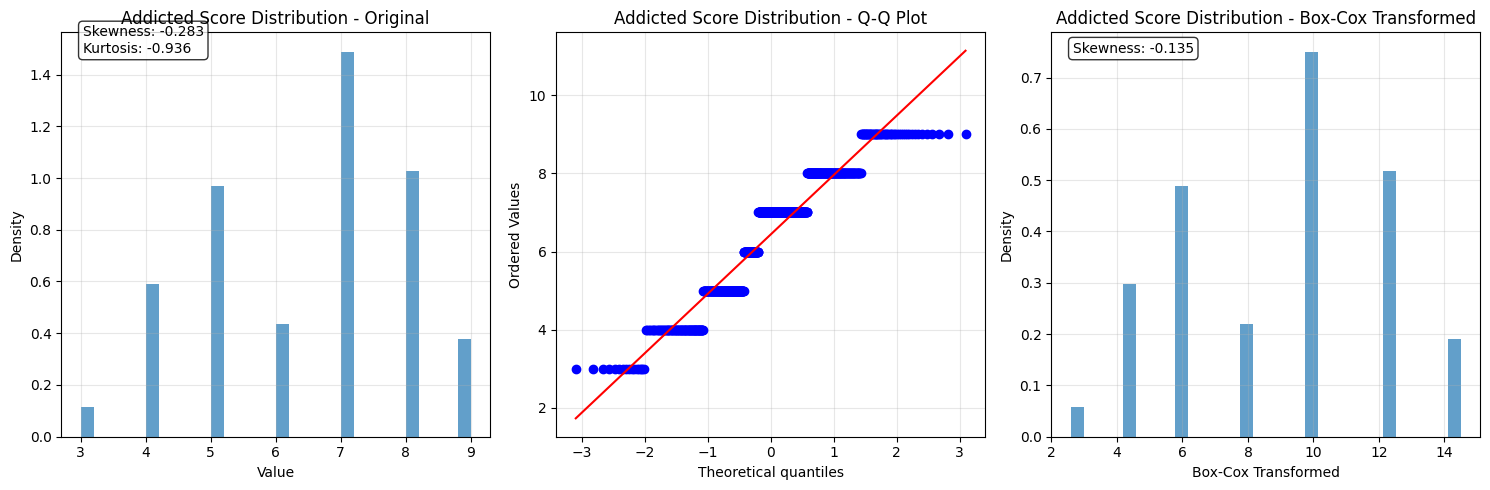

Target Variable Statistics:
skewness: -0.2825
kurtosis: -0.9364
mean: 6.4359
std: 1.5746
min: 3.0000
max: 9.0000
skewness_boxcox: -0.1353


In [5]:
# Analyze target variable distribution
target_stats = check_target_distribution(
    df_data['Addicted_Score'], 
    title="Addicted Score Distribution",
    transform="boxcox"
)

print("Target Variable Statistics:")
for key, value in target_stats.items():
    print(f"{key}: {value:.4f}")


# Data Splitting

As a crucial step for model validation and performance assessment, we divide the dataset into training and testing subsets.

- **Purpose:** The training set is used to fit the model, while the test set evaluates its predictive performance on unseen data.
- **Methodology:** Utilizes an 80/20 split to ensure a robust evaluation framework.
- **Random State:** A fixed random state (42) is used to ensure reproducibility of the split.


In [6]:
# Split the data into train and test
from sklearn.model_selection import train_test_split

# Drop unnecessary columns - we're predicting Addicted_Score
drop_cols = ['Student_ID', 'Conflicts', 'Addicted_Score']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    df_data.drop(columns=drop_cols), 
    df_data['Addicted_Score'], 
    test_size=0.2, 
    random_state=random_state
)

# Print the shape of the train and test sets
print(f"Train set shape: {X_train_full.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Target range - Train: {y_train_full.min():.2f} to {y_train_full.max():.2f}")
print(f"Target range - Test: {y_test.min():.2f} to {y_test.max():.2f}")

X_train_full.head()


Train set shape: (561, 10)
Test set shape: (141, 10)
Target range - Train: 3.00 to 9.00
Target range - Test: 3.00 to 9.00


,Age,Gender,Academic_Level,Country,Daily_Usage,Platform,Academic_Affects,Sleep_Hrs,Mental_Health,Relationship_Status
166,20,Female,Undergraduate,Bangladesh,4.9,Instagram,Yes,6.4,5,Single
546,20,Female,Undergraduate,UAE,6.9,Instagram,Yes,6.1,5,In Relationship
285,21,Male,Graduate,UK,5.0,Facebook,Yes,6.6,6,In Relationship
362,20,Female,Undergraduate,Ireland,4.5,TikTok,Yes,7.4,7,Single
111,21,Female,Undergraduate,India,5.8,TikTok,Yes,5.9,6,In Relationship


# Preprocessing Pipeline

This section outlines the preprocessing steps applied to the dataset to prepare it for regression model training. The pipeline uses the same feature engineering approach as the classification task.

- **Feature Engineering:** Converts categorical features into numerical representations
  - **Binary Encoding:** Transforms binary categorical variables into 0/1 format
  - **One-Hot Encoding:** Applies to low and high cardinality categorical features
  - **Rare Category Grouping:** Groups infrequent categories to reduce dimensionality
  - **Geographical Mapping:** Maps countries to continents for regional analysis

- **Numerical Scaling:** Standardizes numerical features for regression models

This preprocessing pipeline ensures consistent input for all regression models.


In [7]:
# Define Column Groups
binary_cats       = ['Gender']         # boolean → 0/1
low_card_cols     = ['Relationship_Status', 'Academic_Level']  # few categories
high_card_cols    = ['Platform']       # group rare then OHE
country_col       = ['Country']        # map to continent
numeric_cols      = X_train_full.select_dtypes(include=['number']).columns

print(f"Binary categorical columns: {binary_cats}")
print(f"Low cardinality columns: {low_card_cols}")
print(f"High cardinality columns: {high_card_cols}")
print(f"Country column: {country_col}")
print(f"Numeric columns: {list(numeric_cols)}")


Binary categorical columns: ['Gender']
Low cardinality columns: ['Relationship_Status', 'Academic_Level']
High cardinality columns: ['Platform']
Country column: ['Country']
Numeric columns: ['Age', 'Daily_Usage', 'Sleep_Hrs', 'Mental_Health']


In [8]:
# Define preprocessing steps
# Boolean → int
binary_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

# Low-cardinality One-Hot
low_card_transformer = OneHotEncoder(handle_unknown='ignore')

# High-cardinality grouping + One-Hot
high_card_transformer = Pipeline([
    ('group_rare', RareCategoryGrouper(min_count=30)),
    ('onehot',    OneHotEncoder(handle_unknown='ignore'))
])

# Country → Continent → One-Hot
country_transformer = Pipeline([
    ('map_continent', CountryToContinentMapper(mapping=country_to_continent)),
    ('onehot',        OneHotEncoder(handle_unknown='ignore'))
])

# Numeric scaling
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('bools',   binary_transformer,   binary_cats),
    ('low_ohe', low_card_transformer, low_card_cols),
    ('high_ohe',high_card_transformer,high_card_cols),
    ('cty_ohe', country_transformer,  country_col),
    ('nums',    numeric_transformer,  numeric_cols),
], remainder='drop')


Transformed feature matrix (first 5 rows):
   Gender_Male  Relationship_Status_Complicated  \
0          0.0                              0.0   
1          0.0                              0.0   
2          1.0                              0.0   
3          0.0                              0.0   
4          0.0                              0.0   

   Relationship_Status_In Relationship  Relationship_Status_Single  \
0                                  0.0                         1.0   
1                                  1.0                         0.0   
2                                  1.0                         0.0   
3                                  0.0                         1.0   
4                                  1.0                         0.0   

   Academic_Level_Graduate  Academic_Level_High School  \
0                      0.0                         0.0   
1                      0.0                         0.0   
2                      1.0                         0.0 

<Figure size 1500x1000 with 0 Axes>

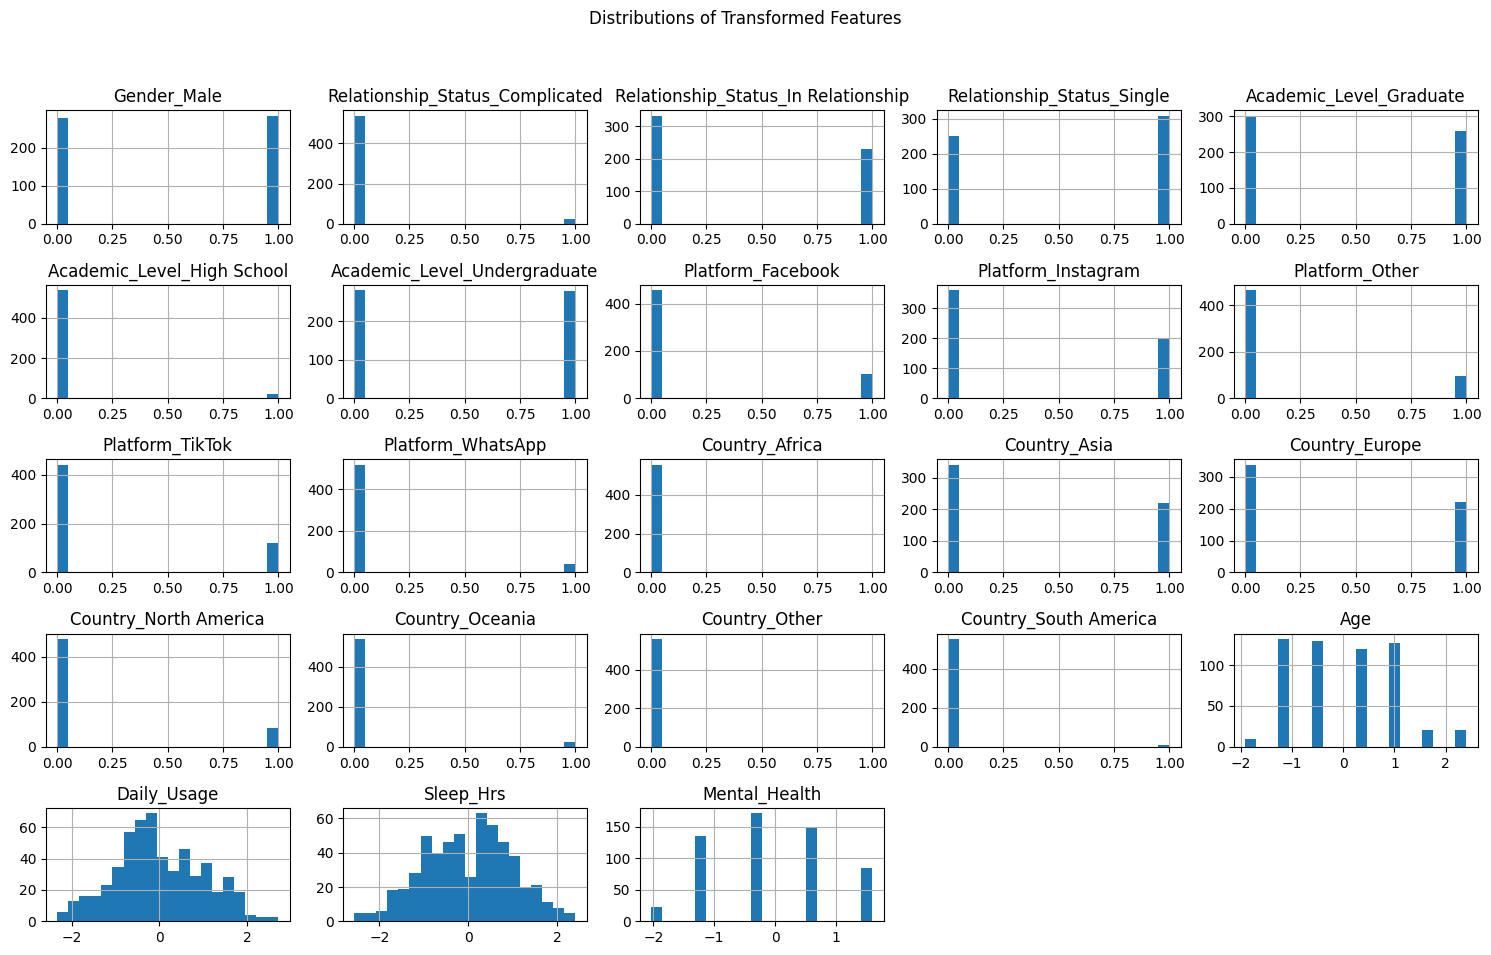

In [9]:
# Apply preprocessing and inspect transformed features
# 1. Fit the preprocessing step on the training data
preprocessor.fit(X_train_full)

# 2. Transform the training data
X_train_proc = preprocessor.transform(X_train_full)

# 3. Retrieve the transformed feature names
feature_names = get_feature_names(preprocessor)

# 4. Convert to DataFrame (densify if sparse)
if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()

X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)

# 5. Print the first few rows
print("Transformed feature matrix (first 5 rows):")
print(X_train_df.head())
print(f"\nTotal features after preprocessing: {len(feature_names)}")

# 6. Simple visualization: histograms for each feature
plt.figure(figsize=(15, 10))
X_train_df.hist(bins=20, figsize=(15, 10))
plt.suptitle("Distributions of Transformed Features")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Dataset Preparation for MLflow

This section prepares dataset objects for MLflow logging, facilitating model reproducibility and experiment tracking.


In [10]:
# Create MLflow dataset objects
train_ds = mlflow.data.from_pandas(
    df=X_train_full,
    source="../data/data_cleaned.pickle",
    name="social_sphere_regression_train_v1"
)
test_ds = mlflow.data.from_pandas(
    df=X_test,
    source="../data/data_cleaned.pickle",
    name="social_sphere_regression_test_v1"
)

# Create dataset dictionary for utility functions
dataset = {
    "train_ds": train_ds,
    "test_ds": test_ds
}

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Define scoring metrics for regression
scoring = {
    "r2": "r2",
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "RMSE": "neg_root_mean_squared_error",
    'MAPE': 'neg_mean_absolute_percentage_error'
}


# Baseline Model: DummyRegressor

Establishing a performance baseline using `DummyRegressor` to set the minimum acceptable performance threshold for more sophisticated models.


In [11]:
# Create baseline dummy regressor pipeline
run_tag = "all_features"
run_name = f"baseline_{run_tag}"

dummy_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', DummyRegressor(strategy='mean'))
])

param_grid_dummy = {
    'regressor__strategy': ['mean', 'median', 'quantile', 'constant']
}

# Run dummy regressor gridsearch experiment
best_baseline_dummy, test_results, *figures = run_regression_gridsearch_experiment(
    name=run_name,
    pipeline=dummy_pipeline,
    param_grid=param_grid_dummy,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=dataset,
    registered_model_name="addicted_score_baseline",
    verbose=True,
    run_tag=run_tag,
    refit_metric="r2"
)

# print("\nBest parameters found:")
# print(best_dummy.best_params_)
# print(f"\nBest CV R² score: {best_dummy.best_score_:.4f}")

print("Baseline dummy regressor experiment completed!")

# Initialint performance dataframe
columns = test_results.keys()
columns = [c for c in columns if c != 'predictions']
# columns
df_performance = pd.DataFrame({k: v for k, v in test_results.items() if k != 'predictions'}, index=[run_name])
df_performance


Fitting 5 folds for each of 4 candidates, totalling 20 fits
r2: -0.0 ± 0.0
MAE: -1.38 ± 0.02
MSE: -2.49 ± 0.09
RMSE: -1.58 ± 0.03
MAPE: -0.25 ± 0.0
Model type: other


Registered model 'addicted_score_baseline' already exists. Creating a new version of this model...
2025/06/29 14:18:16 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: addicted_score_baseline, version 3
Created version '3' of model 'addicted_score_baseline'.


🏃 View run baseline_all_features at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5/runs/c8d394270cc44f11bc8c9cc47f295f2e
🧪 View experiment at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5
Best parameters: {'regressor__strategy': 'mean'}
Best R² score (CV): -0.0
Baseline dummy regressor experiment completed!


,mae,mse,rmse,r2,mape
baseline_all_features,1.339275,2.440805,1.562308,-0.010025,0.235844


# Linear Regression Model

Building a traditional linear regression model for interpretable addiction score prediction. Linear regression provides easily interpretable coefficients showing the relationship between features and addiction levels.


Fitting 5 folds for each of 4 candidates, totalling 20 fits
r2: 0.93 ± 0.01
MAE: -0.32 ± 0.03
MSE: -0.17 ± 0.03
RMSE: -0.41 ± 0.03
MAPE: -0.05 ± 0.01
Model type: linear
Model name: LinearRegression


Registered model 'addicted_score_linear_all_features' already exists. Creating a new version of this model...
2025/06/29 14:18:55 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: addicted_score_linear_all_features, version 2
Created version '2' of model 'addicted_score_linear_all_features'.


🏃 View run linear_all_features at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5/runs/90fb8ebfe1dd405b871e1642d286c703
🧪 View experiment at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5
Best parameters: {'regressor__copy_X': True, 'regressor__fit_intercept': True}
Best R² score (CV): 0.93
Linear regression experiment completed!


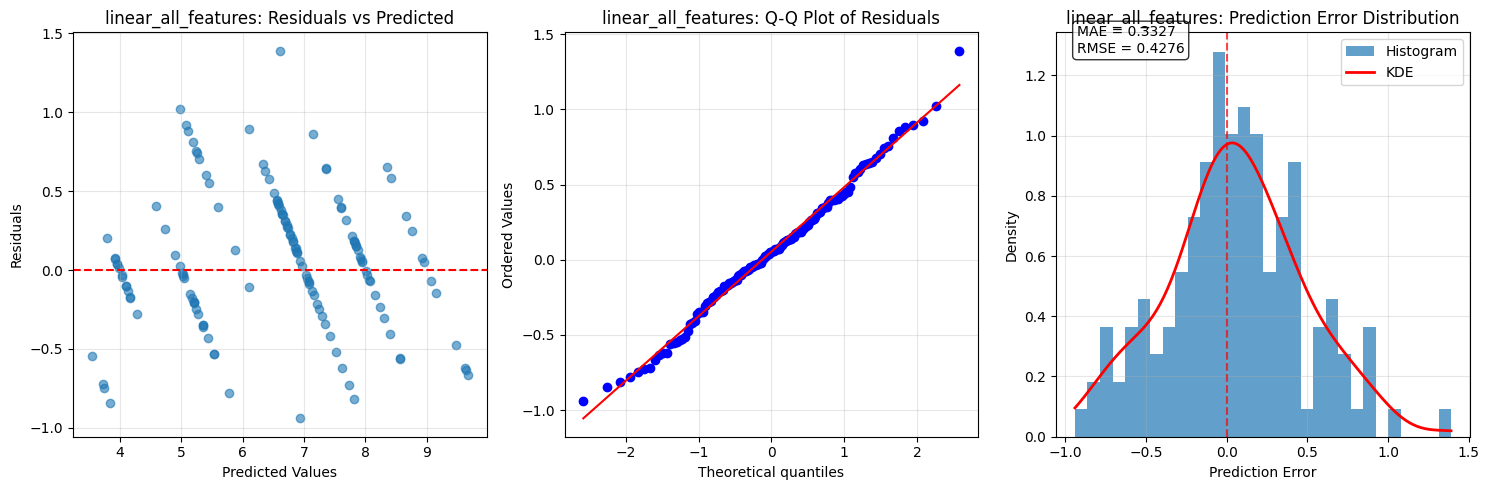

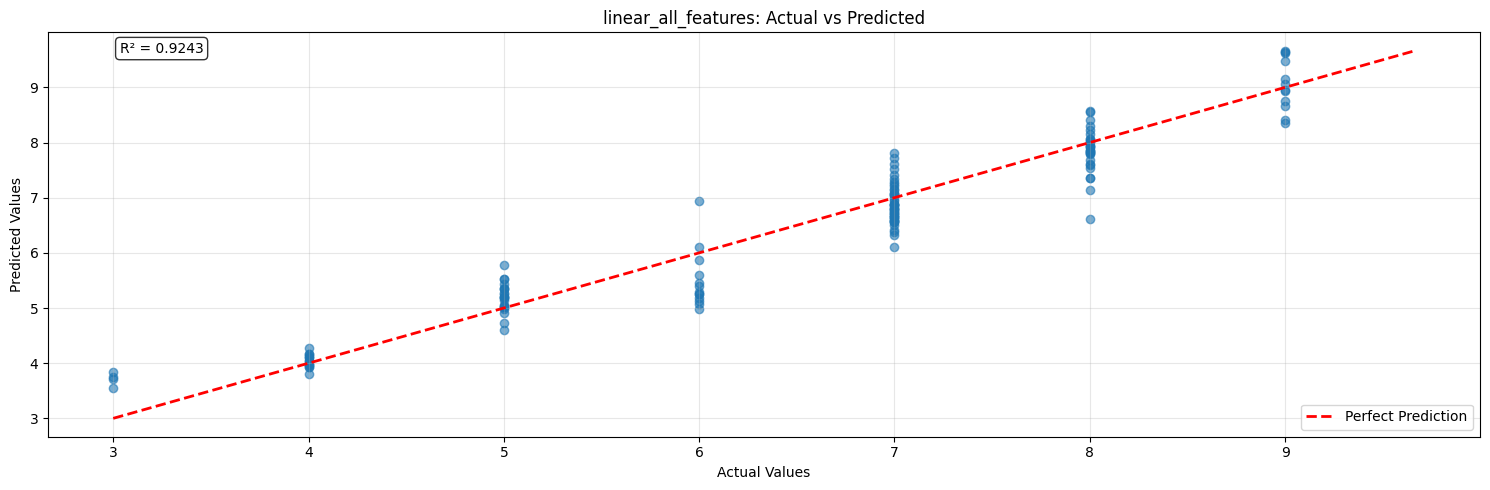

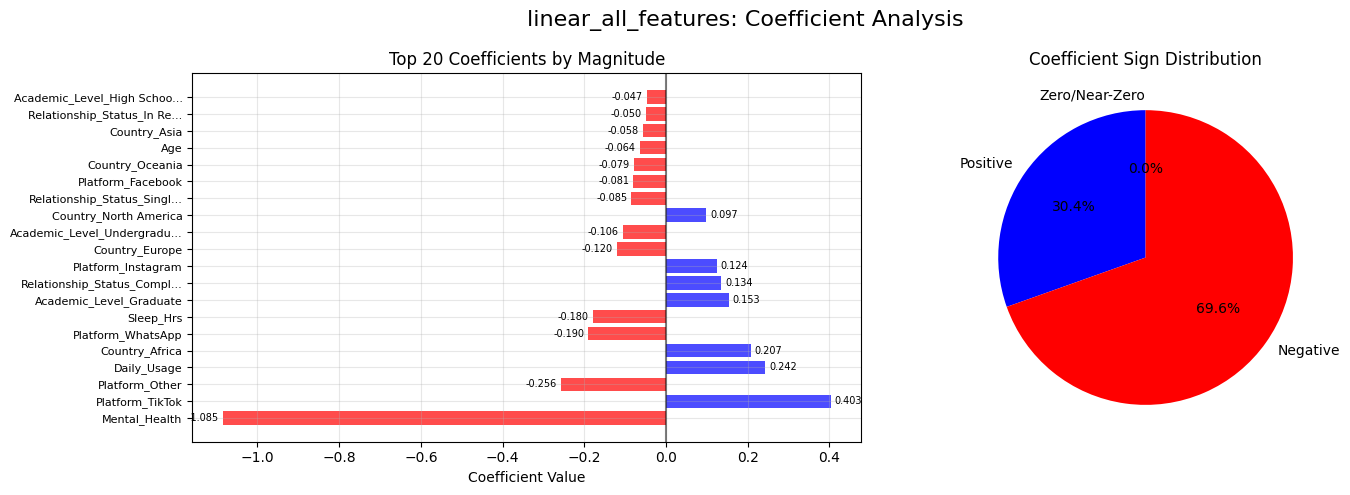

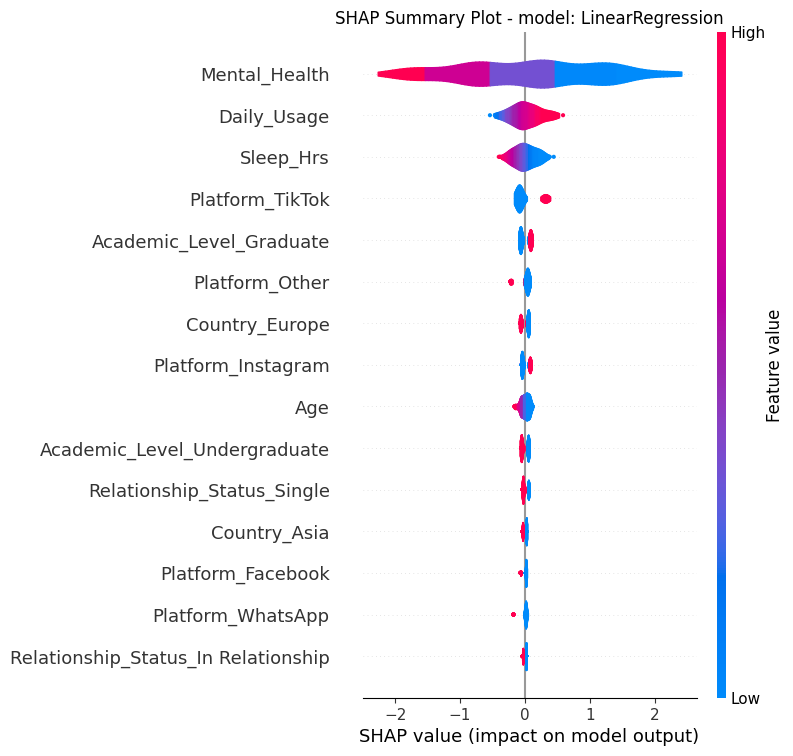

,mae,mse,rmse,r2,mape
baseline_all_features,1.339275,2.440805,1.562308,-0.010025,0.235844
linear_all_features,0.332732,0.182879,0.427643,0.924323,0.054121


In [12]:
run_tag = "all_features"
run_name = f"linear_{run_tag}"

# Create linear regression pipeline
linear_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

param_grid_linear = {
    'regressor__fit_intercept': [True, False],
    'regressor__copy_X': [True, False]
}

# Run linear regression experiment
best_linear, test_results, *figures_linear = run_regression_gridsearch_experiment(
    name=run_name,
    pipeline=linear_pipeline,
    param_grid=param_grid_linear,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=dataset,
    registered_model_name=f"addicted_score_linear_{run_tag}",
    verbose=True,
    run_tag=run_tag,
    refit_metric="r2",
    # round_output = True,
    linear = True
)

print("Linear regression experiment completed!")

for fig in figures_linear:    
    display(fig)

# ===== Log results
# Append new row to existing dataframe instead of creating new one
df_performance.loc[run_name] = {k: v for k, v in test_results.items() if k != 'predictions'}
df_performance

# df_performance.to_csv(f"../data/performance_{run_name}.csv", index=False)

# Rounding Predictions: Integer Output Models

For practical applications, it might be useful to have predictions as integers within the valid range (3-9) since addiction scores are typically discrete values. We'll create a wrapper that rounds predictions and applies bounds.

Fitting 5 folds for each of 4 candidates, totalling 20 fits
r2: 0.91 ± 0.02
MAE: -0.23 ± 0.04
MSE: -0.23 ± 0.04
RMSE: -0.48 ± 0.04
MAPE: -0.04 ± 0.01
Model type: linear
Model name: LinearRegression


Registered model 'addicted_score_linear_all_features+rounded' already exists. Creating a new version of this model...
2025/06/29 14:19:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: addicted_score_linear_all_features+rounded, version 2
Created version '2' of model 'addicted_score_linear_all_features+rounded'.


🏃 View run linear_all_features+rounded at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5/runs/cf8681bc7ff14e07bfb1b57cfb2adc78
🧪 View experiment at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5
Best parameters: {'regressor__regressor__copy_X': True, 'regressor__regressor__fit_intercept': True}
Best R² score (CV): 0.91
Linear regression experiment with rounded predictions completed!


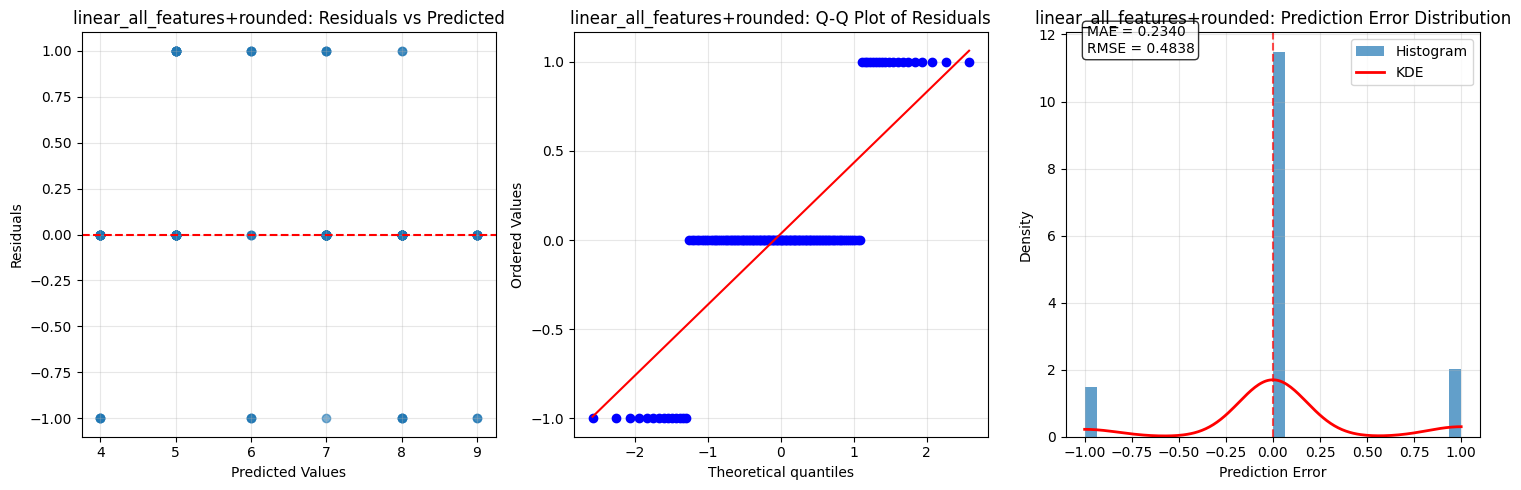

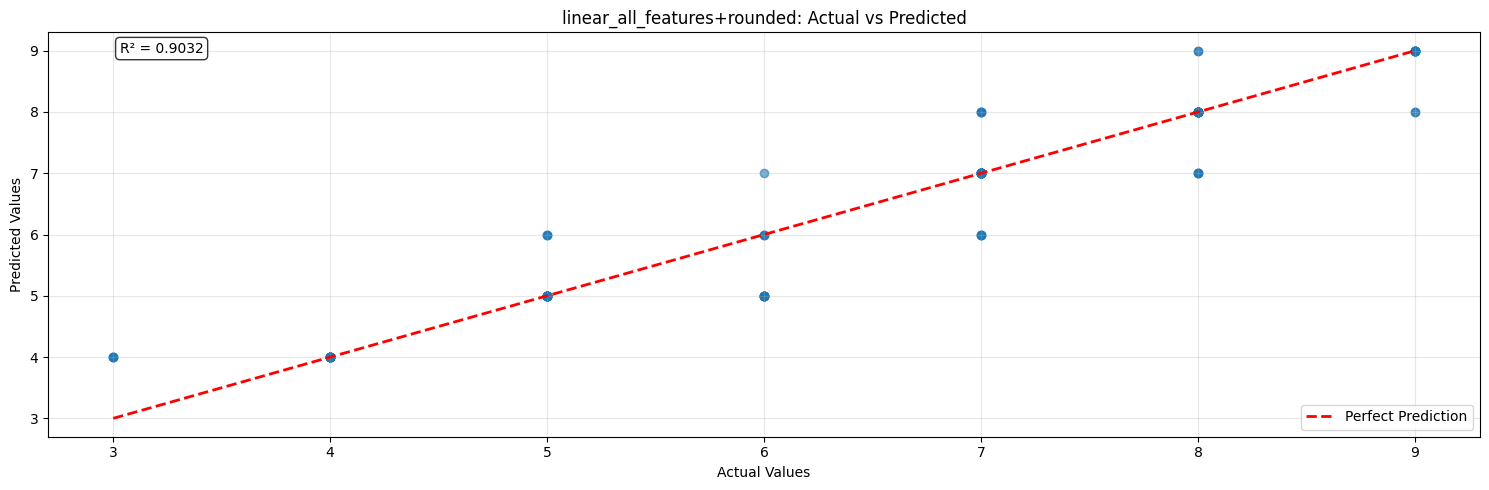

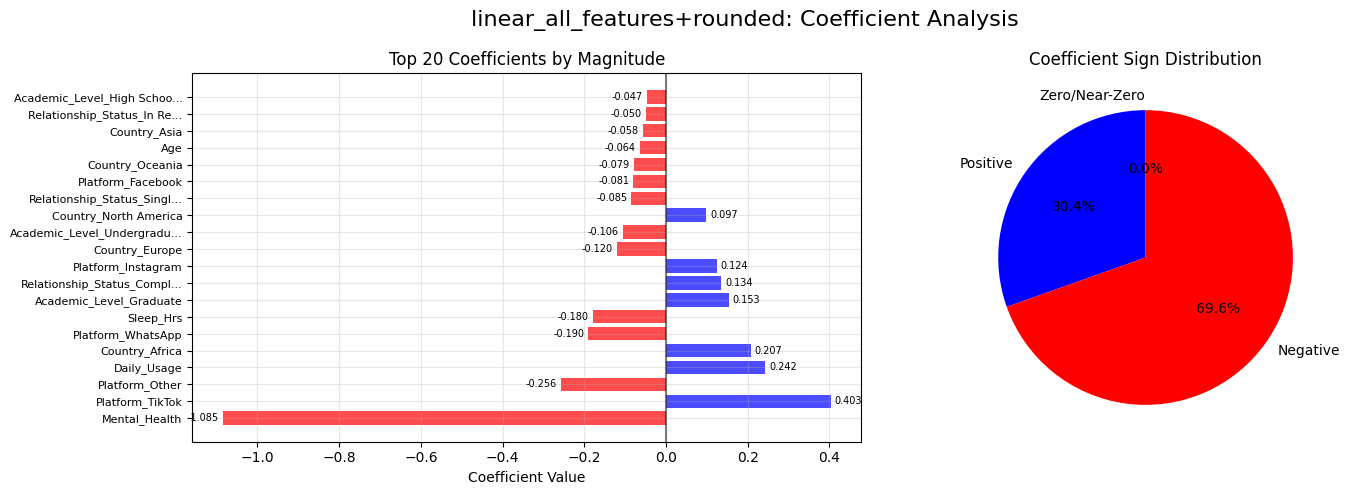

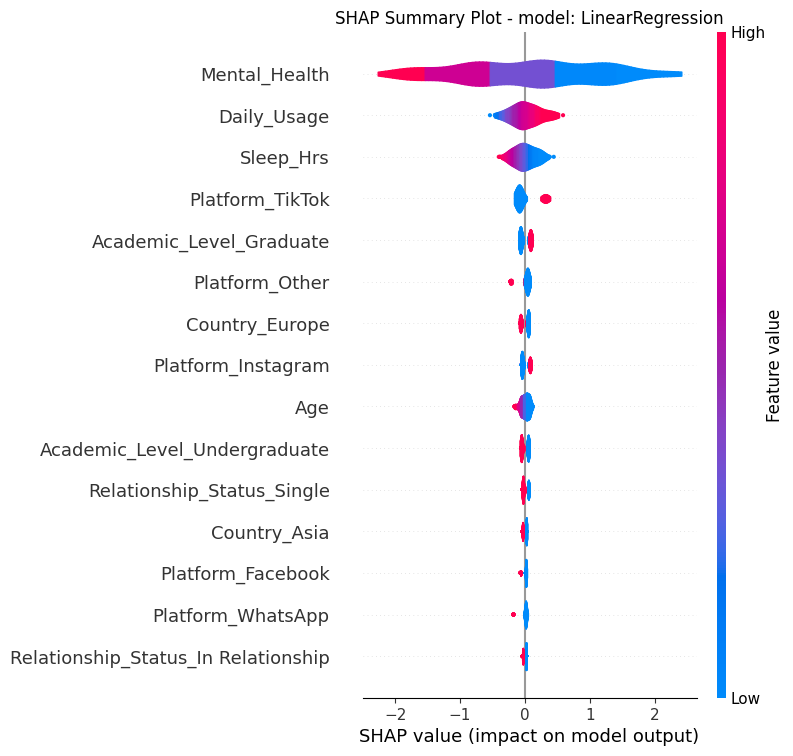

,mae,mse,rmse,r2,mape
baseline_all_features,1.339275,2.440805,1.562308,-0.010025,0.235844
linear_all_features,0.332732,0.182879,0.427643,0.924323,0.054121
linear_all_features+rounded,0.234043,0.234043,0.483779,0.903151,0.040532


In [13]:
run_tag = "all_features+rounded"
run_name = f"linear_{run_tag}"

# Create linear regression pipeline with rounding
linear_pipeline_rounded = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', RoundingRegressor(
        regressor=LinearRegression(),
        min_value=3, 
        max_value=9
    ))
])


param_grid_linear_rounded = { f'regressor__{k}': v for k, v in param_grid_linear.items()}

# Run linear regression experiment with rounding
best_linear_rounded, test_results, *figures_linear_rounded = run_regression_gridsearch_experiment(
    name=run_name,
    pipeline=linear_pipeline_rounded,
    param_grid=param_grid_linear_rounded,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=dataset,
    registered_model_name=f"addicted_score_linear_{run_tag}",
    verbose=True,
    run_tag=run_tag,
    refit_metric="r2",
    linear=True,
    # shap=False
)

print("Linear regression experiment with rounded predictions completed!")

for fig in figures_linear_rounded:    
    display(fig)

# ===== Log results
# Append new row to existing dataframe instead of creating new one
df_performance.loc[run_name] = {k: v for k, v in test_results.items() if k != 'predictions'}
df_performance

# Preparing Preprocessors for Different Feature Sets

We'll create preprocessors for both feature sets:
- **All features**: Uses all available features including Mental Health
- **No Mental Health**: Excludes the Mental Health feature to test model performance without this potentially sensitive variable

In [ ]:
# Define numeric columns without Mental Health
numeric_cols_no_mh = [c for c in numeric_cols if c != 'Mental_Health']

# Create preprocessor without Mental Health
preprocessor_no_mh = ColumnTransformer([
    ('bools',   binary_transformer,   binary_cats),
    ('low_ohe', low_card_transformer, low_card_cols),
    ('high_ohe',high_card_transformer,high_card_cols),
    ('cty_ohe', country_transformer,  country_col),
    ('nums',    numeric_transformer,  numeric_cols_no_mh),
], remainder='drop')

print(f"Numeric columns without Mental Health: {list(numeric_cols_no_mh)}")
print(f"All numeric columns: {list(numeric_cols)}")


Numeric columns without Mental Health: ['Age', 'Daily_Usage', 'Sleep_Hrs']
All numeric columns: ['Age', 'Daily_Usage', 'Sleep_Hrs', 'Mental_Health']


Fitting 5 folds for each of 4 candidates, totalling 20 fits
r2: 0.76 ± 0.04
MAE: -0.51 ± 0.08
MSE: -0.58 ± 0.1
RMSE: -0.76 ± 0.07
MAPE: -0.09 ± 0.01
Model type: linear
Model name: LinearRegression


Registered model 'addicted_score_linear_no_mh+rounded' already exists. Creating a new version of this model...
2025/06/29 14:20:15 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: addicted_score_linear_no_mh+rounded, version 2
Created version '2' of model 'addicted_score_linear_no_mh+rounded'.


🏃 View run linear_no_mh+rounded at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5/runs/b2bbb77378504ff49d6c6d4e27d4290a
🧪 View experiment at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5
Best parameters: {'regressor__regressor__copy_X': True, 'regressor__regressor__fit_intercept': True}
Best R² score (CV): 0.76
Linear regression experiment without Mental Health completed!


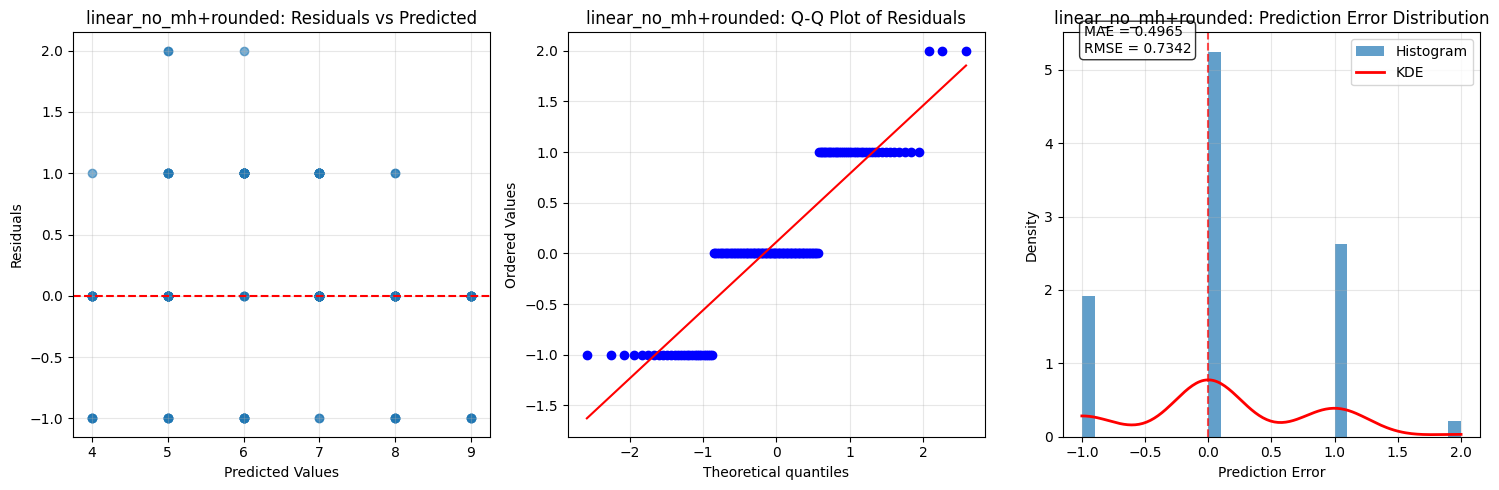

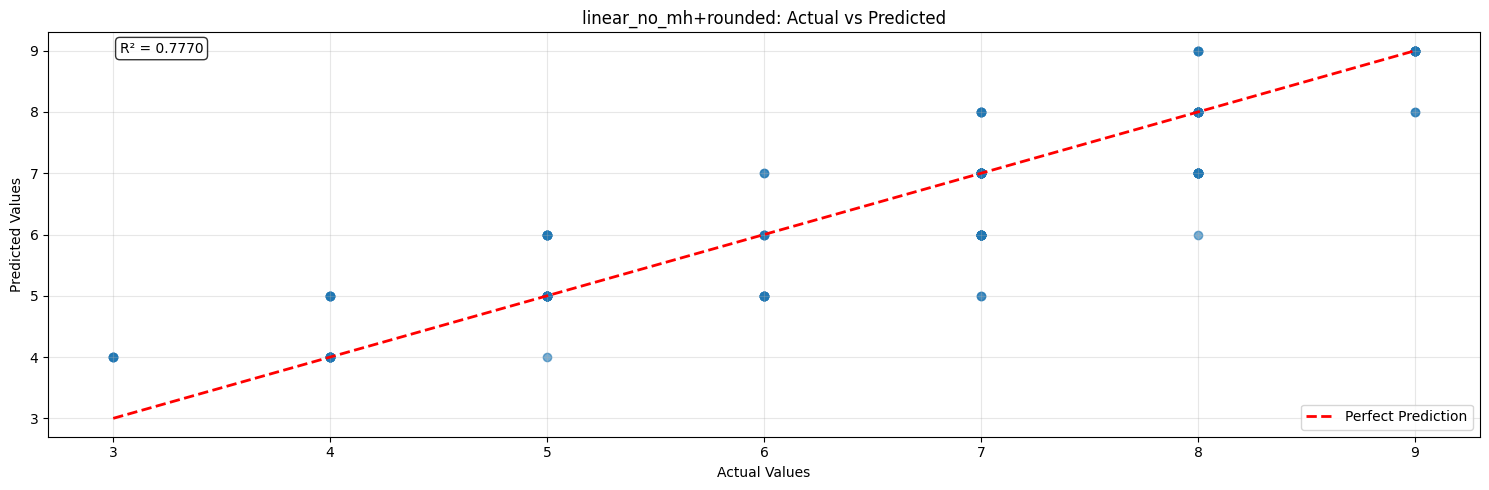

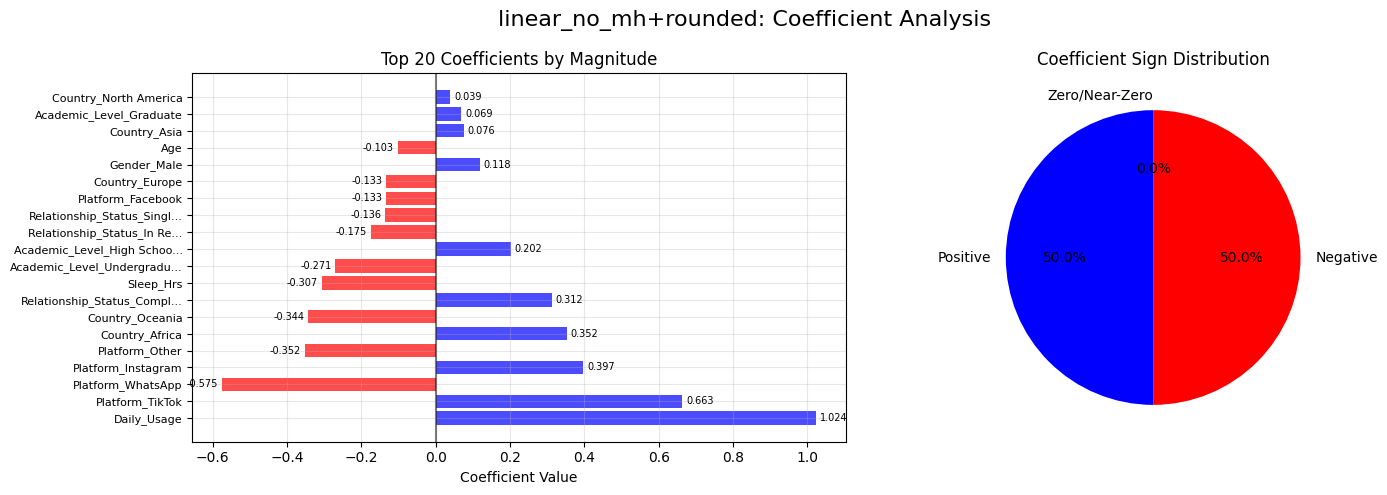

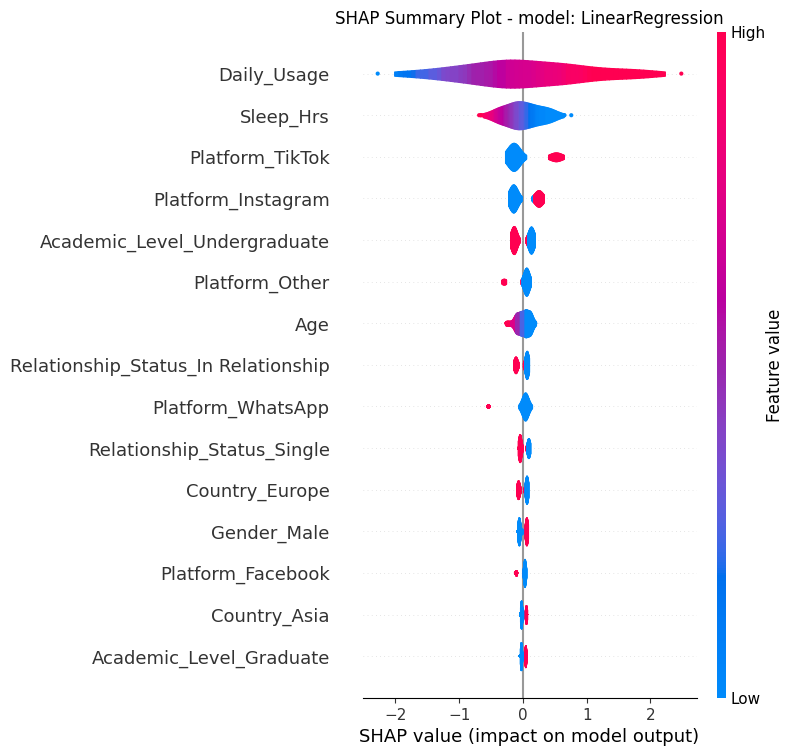

,mae,mse,rmse,r2,mape
baseline_all_features,1.339275,2.440805,1.562308,-0.010025,0.235844
linear_all_features,0.332732,0.182879,0.427643,0.924323,0.054121
linear_all_features+rounded,0.234043,0.234043,0.483779,0.903151,0.040532
linear_no_mh+rounded,0.496454,0.539007,0.734171,0.776954,0.082157


In [15]:
run_tag="no_mh+rounded"
run_name = f"linear_{run_tag}"

numeric_cols_no_mh = [c for c in numeric_cols if c != 'Mental_Health']
linear_pipeline_no_mh = clone(linear_pipeline_rounded)
preprocessor_no_mh = linear_pipeline_no_mh.named_steps['preprocessing']
preprocessor_no_mh.transformers[4] = (
    'nums', numeric_transformer, numeric_cols_no_mh
)
linear_pipeline_no_mh.named_steps['preprocessing'] = preprocessor_no_mh


# Run linear regression experiment
best_linear_no_mh, test_results, *figures_linear_no_mh = run_regression_gridsearch_experiment(
    name=run_name,
    pipeline=linear_pipeline_no_mh,
    param_grid=param_grid_linear_rounded,
    X_train=X_train_full,
    y_train=y_train_full,
    X_test=X_test,
    y_test=y_test,
    cv=cv,
    scoring=scoring,
    dataset=dataset,
    registered_model_name=f"addicted_score_linear_{run_tag}",
    verbose=True,
    run_tag=run_tag,
    refit_metric="r2",
    linear=True,
    # shap=False
)

print("Linear regression experiment without Mental Health completed!")

for fig in figures_linear_no_mh:    
    display(fig)

# ===== Log results
# Append new row to existing dataframe instead of creating new one
df_performance.loc[run_name] = {k: v for k, v in test_results.items() if k != 'predictions'}
df_performance

# Lasso Regression

Lasso (Least Absolute Shrinkage and Selection Operator) is a linear regression technique that performs both variable selection and regularization. It helps enhance the prediction accuracy and interpretability of the model by:

- **Feature Selection**: Lasso automatically selects the most important features by shrinking less important ones to zero.
- **Handling Multicollinearity**: It effectively manages correlated predictors by choosing among them.
- **Preventing Overfitting**: Regularization reduces model complexity, improving generalization to new data.

Key Parameters:
- **`alpha`**: Controls the strength of regularization. Lower values allow more features, while higher values increase sparsity.
- **`max_iter`**: Maximum number of iterations for convergence. Ensure it's high enough to avoid warnings.
- **`selection`**: Algorithm for coordinate descent. 'Random' is often faster than 'cyclic'.

Benefits:
- **Sparse Models**: Clear feature importance with fewer predictors.
- **Improved Interpretability**: Easier to understand which features drive predictions.
- **Robustness**: Reduces the risk of overfitting, especially in high-dimensional datasets.

Lasso is particularly useful when you have many features and expect only a few to be significant.

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
r2: 0.92 ± 0.01
MAE: -0.21 ± 0.03
MSE: -0.21 ± 0.03
RMSE: -0.46 ± 0.04
MAPE: -0.04 ± 0.01
Model type: linear
Model name: Lasso


Successfully registered model 'addicted_score_lasso_all_features+rounded'.
2025/06/29 14:20:55 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: addicted_score_lasso_all_features+rounded, version 1
Created version '1' of model 'addicted_score_lasso_all_features+rounded'.


🏃 View run lasso_all_features+rounded at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5/runs/8b8f0678f9cb459a972b7fdc3ccb5808
🧪 View experiment at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5
Best parameters: {'regressor__regressor__alpha': 0.01, 'regressor__regressor__fit_intercept': True, 'regressor__regressor__max_iter': 1000, 'regressor__regressor__selection': 'random', 'regressor__regressor__tol': 0.001}
Best R² score (CV): 0.92
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
r2: 0.76 ± 0.04
MAE: -0.51 ± 0.08
MSE: -0.58 ± 0.1
RMSE: -0.76 ± 0.07
MAPE: -0.09 ± 0.01
Model type: linear
Model name: Lasso


Registered model 'addicted_score_lasso_no_mh+rounded' already exists. Creating a new version of this model...
2025/06/29 14:21:36 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: addicted_score_lasso_no_mh+rounded, version 2
Created version '2' of model 'addicted_score_lasso_no_mh+rounded'.


🏃 View run lasso_no_mh+rounded at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5/runs/ec73d12f1aad4099ae068cbe3ccf8a67
🧪 View experiment at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5
Best parameters: {'regressor__regressor__alpha': 0.001, 'regressor__regressor__fit_intercept': True, 'regressor__regressor__max_iter': 1000, 'regressor__regressor__selection': 'cyclic', 'regressor__regressor__tol': 0.0001}
Best R² score (CV): 0.76


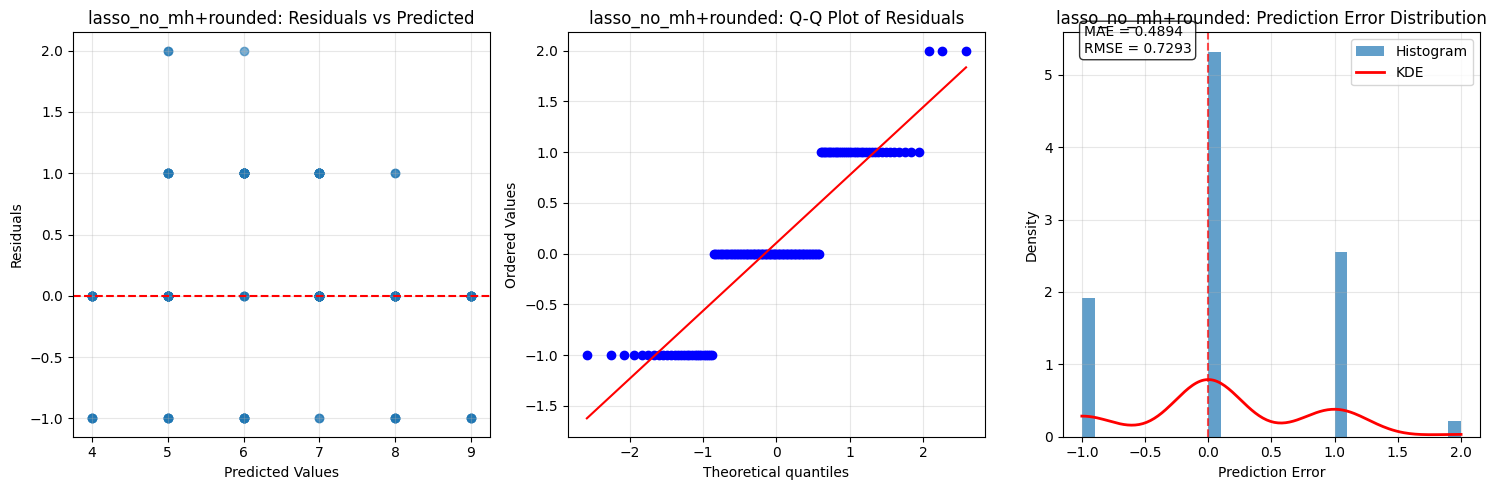

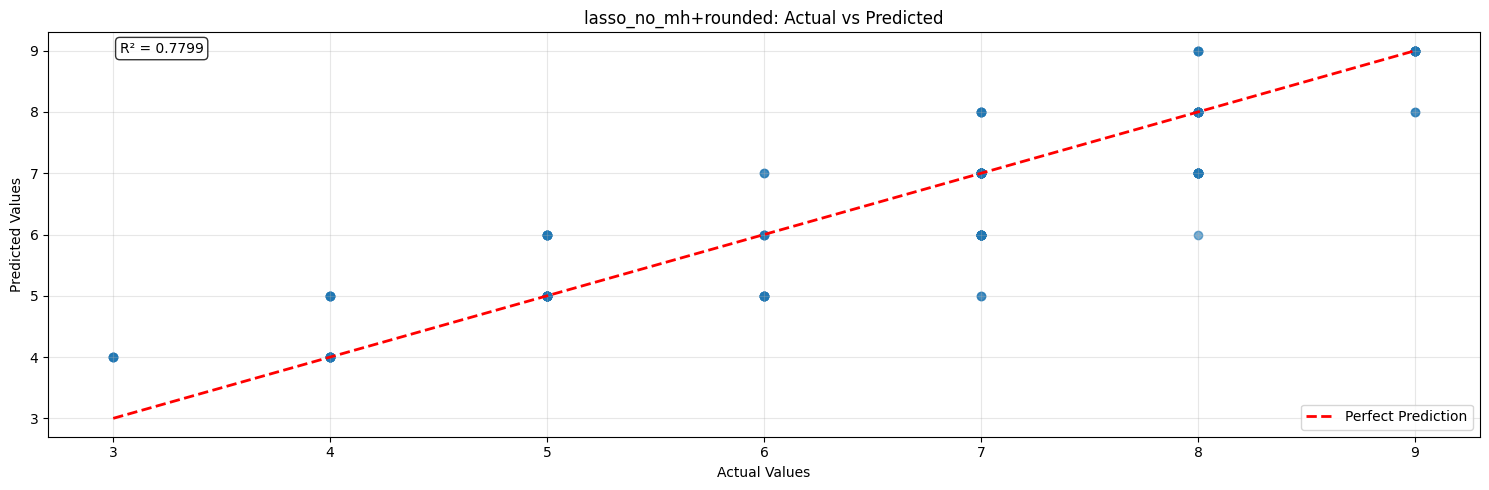

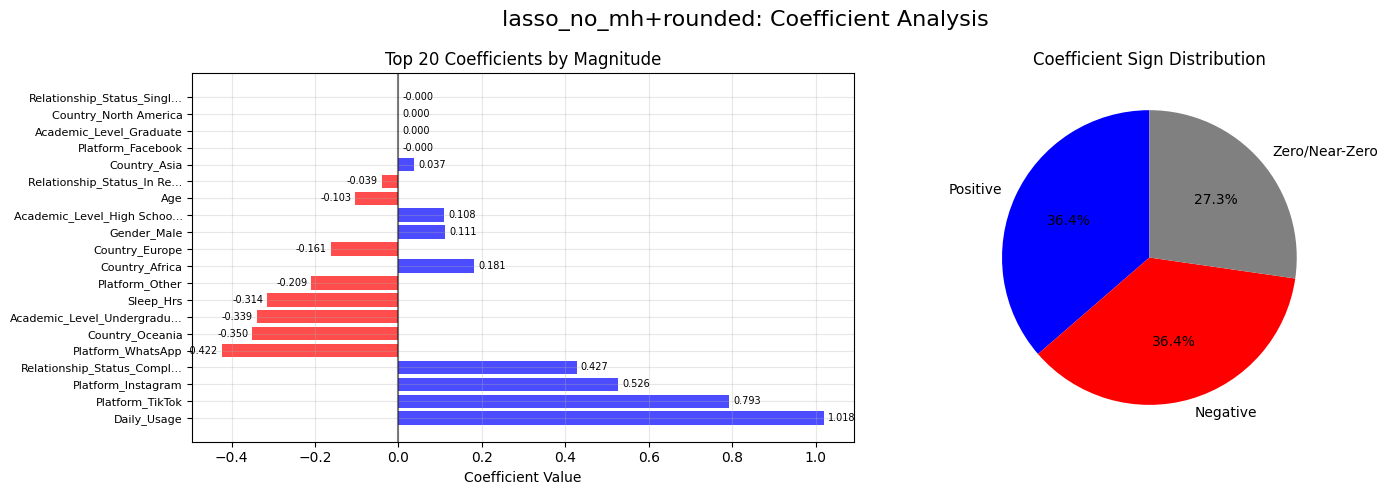

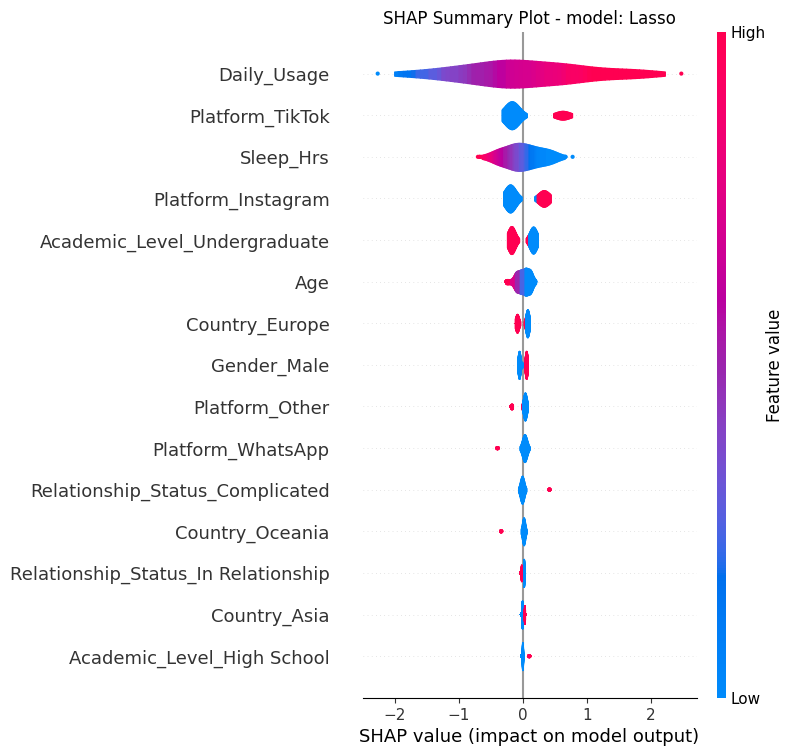

In [16]:
run_tags = ["all_features+rounded","no_mh+rounded"]

# Proper parameter grid for Lasso
param_grid_lasso = {
    'regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0],
    'regressor__fit_intercept': [True, False],
    'regressor__max_iter': [1000, 2000, 5000],
    'regressor__selection': ['cyclic', 'random'],
    'regressor__tol': [1e-4, 1e-3, 1e-2]
}
param_grid_lasso = { f'regressor__{k}': v for k, v in param_grid_lasso.items()}

figures = {}
# ===== Lasso experiments
for run_tag in run_tags:
    run_name = f"lasso_{run_tag}"

    if "no_mh" in run_tag:
        preprocessor_run = preprocessor_no_mh
    else:
        preprocessor_run = preprocessor

    # Create Lasso pipeline
    lasso_pipeline = Pipeline([
        ('preprocessing', preprocessor_run),
        ('regressor', RoundingRegressor(
            regressor=Lasso(random_state=42),
            min_value=3, 
            max_value=9
        ))
    ])


    # Run the grid search experiment with coefficient analysis
    best_lasso, test_results, *figures_lasso = run_regression_gridsearch_experiment(
        name=run_name,
        pipeline=lasso_pipeline,
        param_grid=param_grid_lasso,
        X_train=X_train_full, 
        y_train=y_train_full,
        X_test=X_test, 
        y_test=y_test,
        cv=cv,
        scoring=scoring,
        dataset=dataset,
        registered_model_name=f"addicted_score_lasso_{run_tag}",
        run_tag=run_tag,
        verbose=True,
        refit_metric="r2",
        linear=True  # This will show which features Lasso selected
    )

    figures[run_tag] = figures_lasso

    # ===== Log results
    # Append new row to existing dataframe instead of creating new one
    df_performance.loc[run_name] = {k: v for k, v in test_results.items() if k != 'predictions'}
    df_performance

# ===== Show coefficient, SHAP, and Prediction plots
for fig in figures['no_mh+rounded']:
    display(fig)



# XGBoost Regression Model

Fitting 5 folds for each of 16 candidates, totalling 80 fits
r2: 0.97 ± 0.01
MAE: -0.07 ± 0.02
MSE: -0.07 ± 0.02
RMSE: -0.26 ± 0.03
MAPE: -0.01 ± 0.0
Model type: tree
Model name: XGBRegressor
Tree SHAP plot type: violin


Successfully registered model 'addicted_score_xgb_all_features+rounded'.
2025/06/29 14:22:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: addicted_score_xgb_all_features+rounded, version 1
Created version '1' of model 'addicted_score_xgb_all_features+rounded'.


🏃 View run xgb_all_features+rounded at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5/runs/b50b7e9daa08426c92ee94ba94bbf260
🧪 View experiment at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5
Best parameters: {'regressor__regressor__colsample_bytree': 0.8, 'regressor__regressor__learning_rate': 0.1, 'regressor__regressor__max_depth': 6, 'regressor__regressor__n_estimators': 200, 'regressor__regressor__reg_alpha': 0, 'regressor__regressor__reg_lambda': 1, 'regressor__regressor__subsample': 0.8}
Best R² score (CV): 0.97
Fitting 5 folds for each of 16 candidates, totalling 80 fits
r2: 0.87 ± 0.04
MAE: -0.26 ± 0.06
MSE: -0.33 ± 0.09
RMSE: -0.57 ± 0.08
MAPE: -0.05 ± 0.01
Model type: tree
Model name: XGBRegressor
Tree SHAP plot type: violin


Registered model 'addicted_score_xgb_no_mh+rounded' already exists. Creating a new version of this model...
2025/06/29 14:22:53 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: addicted_score_xgb_no_mh+rounded, version 2
Created version '2' of model 'addicted_score_xgb_no_mh+rounded'.


🏃 View run xgb_no_mh+rounded at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5/runs/846027d6f315422ba0d8a340d4b8122d
🧪 View experiment at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5
Best parameters: {'regressor__regressor__colsample_bytree': 0.8, 'regressor__regressor__learning_rate': 0.1, 'regressor__regressor__max_depth': 6, 'regressor__regressor__n_estimators': 100, 'regressor__regressor__reg_alpha': 1, 'regressor__regressor__reg_lambda': 1, 'regressor__regressor__subsample': 0.8}
Best R² score (CV): 0.87
XGBoost experiments completed!


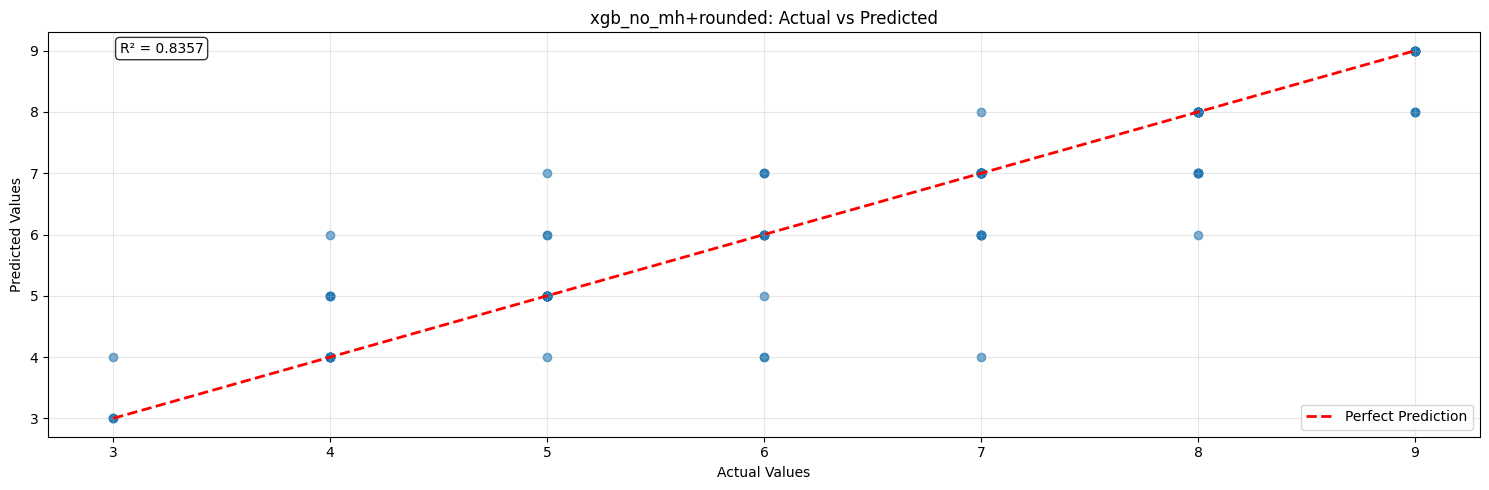

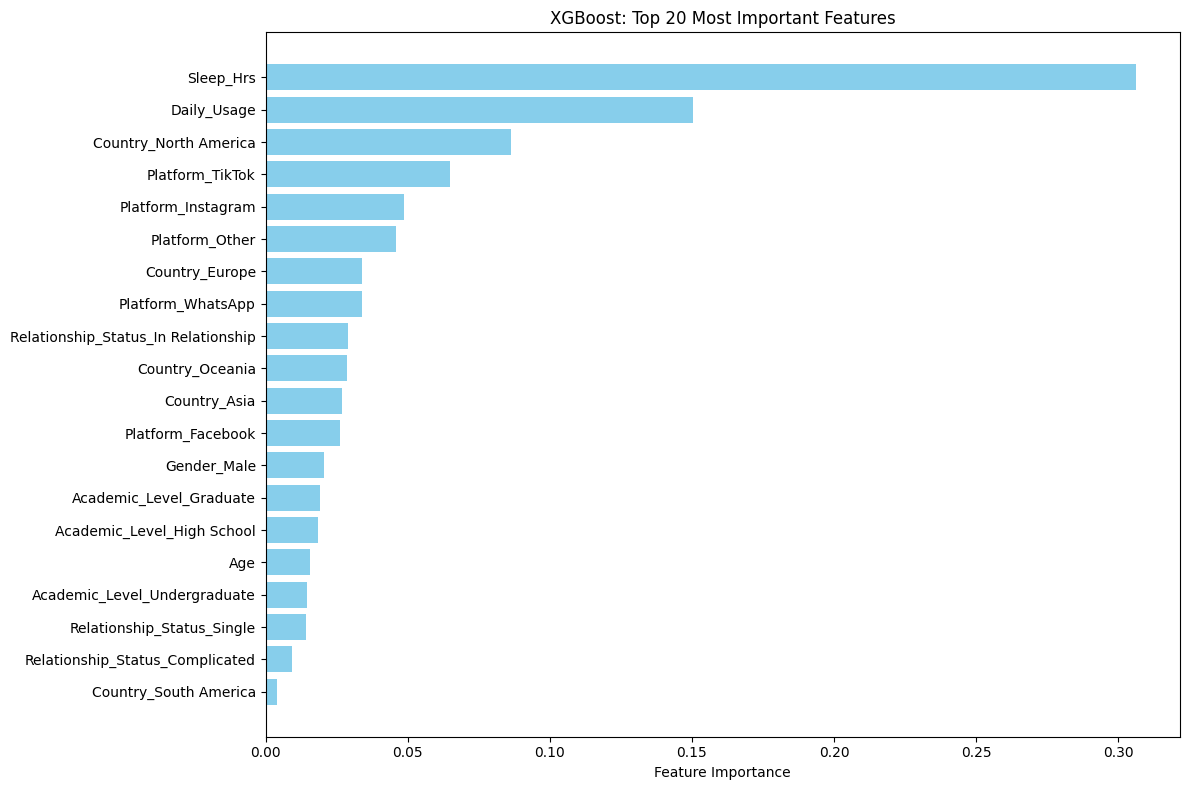

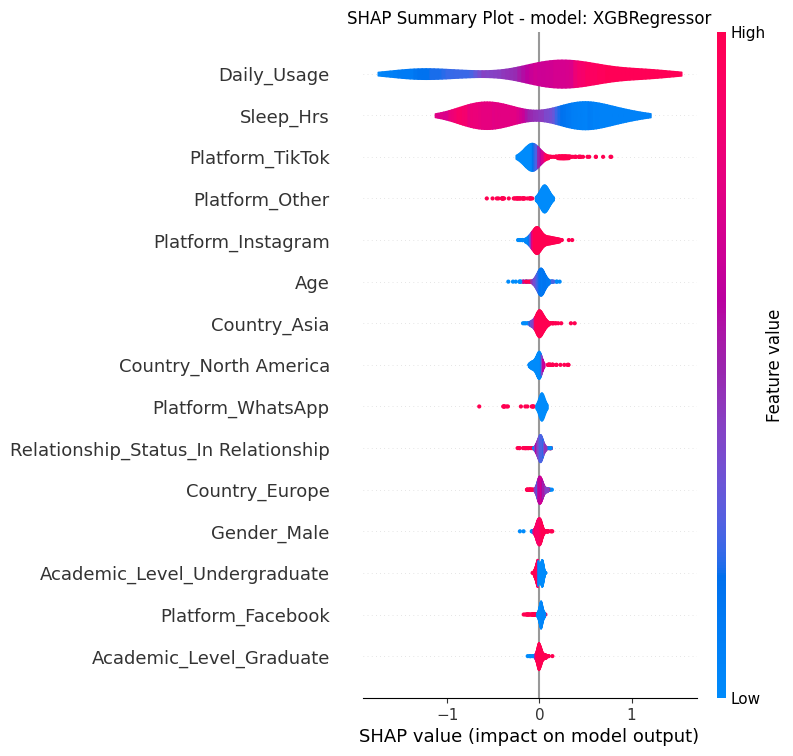

In [17]:

run_tags = ["all_features+rounded", "no_mh+rounded"]

# Compact parameter grid for XGBoost (faster search)
param_grid_xgb_compact = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [4, 6],
    'regressor__learning_rate': [0.1, 0.2],
    'regressor__subsample': [0.8],
    'regressor__colsample_bytree': [0.8],
    'regressor__reg_alpha': [0, 1],
    'regressor__reg_lambda': [1]
}
param_grid_xgb_compact = {f'regressor__{k}': v for k, v in param_grid_xgb_compact.items()}

figures = {}
# ===== XGBoost experiments
for run_tag in run_tags:
    run_name = f"xgb_{run_tag}"

    if "no_mh" in run_tag:
        preprocessor_run = preprocessor_no_mh
    else:
        preprocessor_run = preprocessor

    # Create XGBoost pipeline
    xgb_pipeline = Pipeline([
        ('preprocessing', preprocessor_run),
        ('regressor', RoundingRegressor(
            XGBRegressor(random_state=42, n_jobs=-1), 
            min_value=3, max_value=9)
        )
    ])

    # Run the grid search experiment
    best_xgb, test_results, *figures_xgb = run_regression_gridsearch_experiment(
        name=run_name,
        pipeline=xgb_pipeline,
        param_grid=param_grid_xgb_compact,
        X_train=X_train_full, 
        y_train=y_train_full,
        X_test=X_test, 
        y_test=y_test,
        cv=cv,
        scoring=scoring,
        dataset=dataset,
        registered_model_name=f"addicted_score_xgb_{run_tag}",
        verbose=True,
        run_tag=run_tag,
        refit_metric="r2"
    )

    figures[run_tag] = figures_xgb

    # ===== Log results
    # Append new row to existing dataframe instead of creating new one
    df_performance.loc[run_name] = {k: v for k, v in test_results.items() if k != 'predictions'}
    df_performance

print("XGBoost experiments completed!")

# ===== Show SHAP and Prediction plots
for fig in figures['no_mh+rounded']:
    display(fig)

# CatBoost Regression Model

Implementing CatBoost regressor for advanced gradient boosting performance. CatBoost handles categorical features well and often provides superior predictive performance compared to linear models.


Fitting 5 folds for each of 27 candidates, totalling 135 fits
r2: 0.98 ± 0.0
MAE: -0.15 ± 0.02
MSE: -0.06 ± 0.01
RMSE: -0.24 ± 0.02
MAPE: -0.02 ± 0.0
Model type: tree
Model name: CatBoostRegressor
CatBoost SHAP plot type: bar


Successfully registered model 'addicted_score_catboost_all_features+rounded'.
2025/06/29 14:23:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: addicted_score_catboost_all_features+rounded, version 1
Created version '1' of model 'addicted_score_catboost_all_features+rounded'.


🏃 View run catboost_all_features+rounded at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5/runs/49c239089ecc4fd88af945b5497c08bb
🧪 View experiment at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5
Best parameters: {'regressor__depth': 8, 'regressor__iterations': 300, 'regressor__learning_rate': 0.1}
Best R² score (CV): 0.98
Fitting 5 folds for each of 27 candidates, totalling 135 fits
r2: 0.93 ± 0.01
MAE: -0.29 ± 0.03
MSE: -0.18 ± 0.03
RMSE: -0.42 ± 0.03
MAPE: -0.05 ± 0.0
Model type: tree
Model name: CatBoostRegressor
CatBoost SHAP plot type: bar


Registered model 'addicted_score_catboost_no_mh+rounded' already exists. Creating a new version of this model...
2025/06/29 14:24:10 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: addicted_score_catboost_no_mh+rounded, version 2
Created version '2' of model 'addicted_score_catboost_no_mh+rounded'.


🏃 View run catboost_no_mh+rounded at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5/runs/e3bb9a11e55b46159e8a5a790b27c708
🧪 View experiment at: https://dagshub.com/bab-git/SDS-social-sphere.mlflow/#/experiments/5
Best parameters: {'regressor__depth': 6, 'regressor__iterations': 300, 'regressor__learning_rate': 0.1}
Best R² score (CV): 0.93
CatBoost experiments completed!


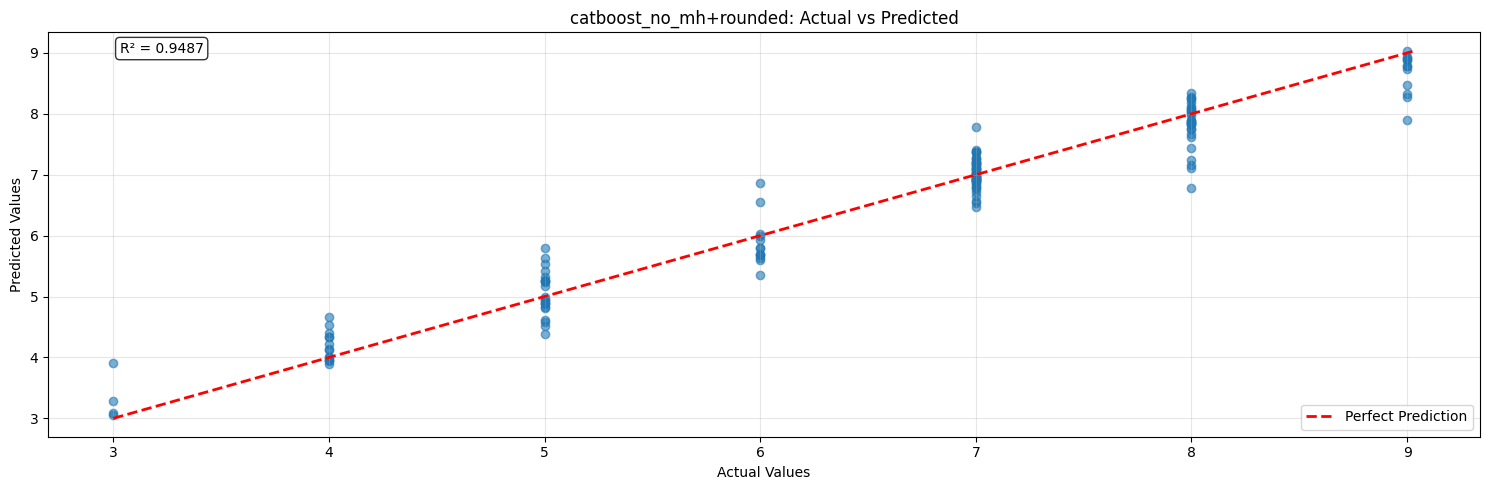

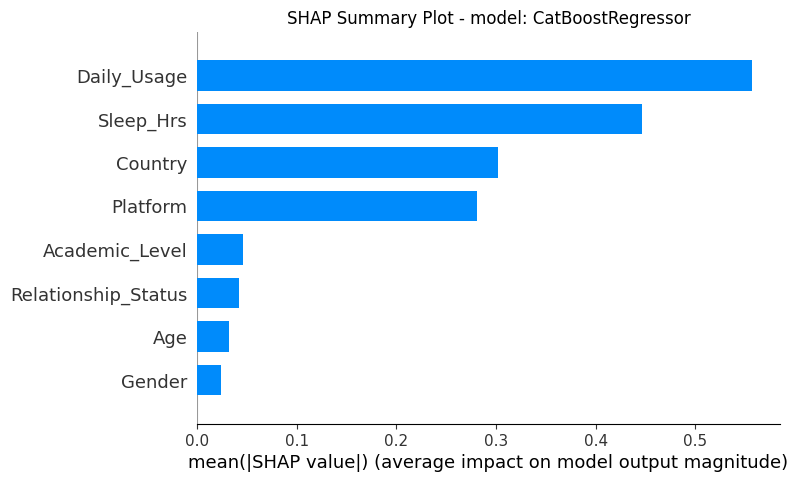

In [18]:
run_tags = ["all_features+rounded", "no_mh+rounded"]

# Create CatBoost regression pipeline components
categorical_features = binary_cats + low_card_cols + high_card_cols + country_col

param_grid_catboost = {
    'regressor__iterations': [100, 200, 300],
    'regressor__learning_rate': [0.03, 0.1, 0.2],
    'regressor__depth': [4, 6, 8]
}

figures = {}
# ===== CatBoost experiments
for run_tag in run_tags:
    run_name = f"catboost_{run_tag}"

    if "no_mh" in run_tag:
        numeric_cols_run = numeric_cols_no_mh
    else:
        numeric_cols_run = numeric_cols

    # Create preprocessor for CatBoost
    preprocessor_catboost = ColumnTransformer([
        ('cats', 'passthrough', categorical_features),
        ('nums', numeric_transformer, numeric_cols_run),
    ], remainder='drop')

    # Create CatBoost pipeline
    catboost_pipeline = Pipeline([
        ('preprocessing', preprocessor_catboost),
        ('regressor', CatBoostRegressor(
                cat_features=list(range(len(categorical_features))),
                random_state=random_state,
                verbose=False,
                iterations=100
            )        
        )
    ])

    # Run the grid search experiment
    best_catboost, test_results, *figures_catboost = run_regression_gridsearch_experiment(
        name=run_name,
        pipeline=catboost_pipeline,
        param_grid=param_grid_catboost,
        X_train=X_train_full, 
        y_train=y_train_full,
        X_test=X_test, 
        y_test=y_test,
        cv=cv,
        scoring=scoring,
        dataset=dataset,
        registered_model_name=f"addicted_score_catboost_{run_tag}",
        run_tag=run_tag,
        verbose=True,
        refit_metric="r2",
        coeff_profile=False
    )

    figures[run_tag] = figures_catboost

    # ===== Log results
    # Append new row to existing dataframe instead of creating new one
    df_performance.loc[run_name] = {k: v for k, v in test_results.items() if k != 'predictions'}
    df_performance

print("CatBoost experiments completed!")

# ===== Show SHAP and Prediction plots
for fig in figures['no_mh+rounded']:
    display(fig)
